# 2026 March Madness Analytics

Data-driven bracket and Roster Madness analysis using KenPom efficiency ratings,
historical champion filters, injury adjustments, and pool ownership modeling.

**Champion Pick:** Arizona  
**Runner-Up:** Michigan  
**Final Four:** Arizona · Michigan · UConn · Houston

---

### Four Core Visualizations
1. **KenPom Scatter Plot** — offense vs defense with hard champion filter lines
2. **Experience Tier Bar Chart** — experience distribution across seed tiers
3. **Upset Tracker Visualization** — confidence and pool value for each upset call
4. **Roster Madness Points Projection** — projected points per pick slot

---

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path('../data')

profiles = pd.read_csv(DATA_DIR / 'team_profiles.csv')
roster = pd.read_csv(DATA_DIR / 'roster_picks.csv')
upsets = pd.read_csv(DATA_DIR / 'upset_tracker.csv')
filters = pd.read_csv(DATA_DIR / 'historical_filters.csv')

print("PROFILES:", profiles.columns.tolist())
print("ROSTER:", roster.columns.tolist())
print("UPSETS:", upsets.columns.tolist())
print("FILTERS:", filters.columns.tolist())

PROFILES: ['team', 'seed', 'region', 'record', 'kenpom_rank', 'kenpom_offense_rank', 'kenpom_defense_rank', 'adjusted_efficiency_margin', 'injury_flag', 'injured_player', 'injury_status', 'ceiling', 'floor', 'ownership_estimate_pct', 'contrarian_value', 'bracket_path_difficulty', 'champion_filter_pass', 'notes']
ROSTER: ['seed_slot', 'team', 'seed', 'region', 'reasoning', 'kenpom_rank', 'projected_round', 'estimated_points_standard', 'estimated_points_upset_bonus', 'pool_ownership_est', 'contrarian_tier', 'key_metric', 'head_coach', 'experience_tier', 'injury_flag', 'star_player']
UPSETS: ['round', 'higher_seed_team', 'higher_seed_num', 'lower_seed_team', 'lower_seed_num', 'upset_tier', 'kenpom_gap', 'kenpom_higher_seed_rank', 'kenpom_lower_seed_rank', 'pool_value_rating', 'confidence', 'primary_reason', 'secondary_reason', 'injury_factor', 'predicted_winner', 'score_projection', 'region']
FILTERS: ['filter', 'verdict', 'rule_type', 'weight', 'years_verified', 'exceptions', 'teams_that

## Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-darkgrid')

# Consistent color palette
COLORS = {
    'primary':   '#1a3a5c',
    'accent':    '#e84545',
    'gold':      '#f5a623',
    'green':     '#27ae60',
    'light_blue':'#5b8db8',
    'danger':    '#d73027',
    'warning':   '#fc8d59',
    'safe':      '#4575b4',
}

# Data directory (relative to this notebook)
DATA_DIR = Path('../data')
RESULTS_DIR = Path('../results')

print('Setup complete.')

Setup complete.


## Load Data

In [3]:
# Load all CSV files
profiles = pd.read_csv(DATA_DIR / 'team_profiles.csv')
stats    = pd.read_csv(DATA_DIR / 'team_stats.csv')
roster   = pd.read_csv(DATA_DIR / 'roster_picks.csv')
upsets   = pd.read_csv(DATA_DIR / 'upset_tracker.csv')
filters  = pd.read_csv(DATA_DIR / 'historical_filters.csv')

# Parse ownership numeric values
profiles['ownership_pct'] = pd.to_numeric(profiles['ownership_estimate_pct'], errors='coerce').fillna(0)
roster['ownership_num'] = pd.to_numeric(roster['pool_ownership_est'], errors='coerce').fillna(0)

# De-duplicate upset rows that appeared twice in source data
upsets_dedup = upsets.drop_duplicates(subset=['higher_seed_team', 'lower_seed_team', 'round']).reset_index(drop=True)

print(f'Team Profiles : {len(profiles)} teams')
print(f'Team Stats    : {len(stats)} teams')
print(f'Roster Picks  : {len(roster)} picks')
print(f'Upset Tracker : {len(upsets_dedup)} unique upset calls')
print(f'Hist. Filters : {len(filters)} filters')

profiles.head(3)

Team Profiles : 29 teams
Team Stats    : 29 teams
Roster Picks  : 16 picks
Upset Tracker : 10 unique upset calls
Hist. Filters : 10 filters


,team,seed,region,record,kenpom_rank,kenpom_offense_rank,kenpom_defense_rank,adjusted_efficiency_margin,injury_flag,injured_player,injury_status,ceiling,floor,ownership_estimate_pct,contrarian_value,bracket_path_difficulty,champion_filter_pass,notes,ownership_pct
0,Arizona,1,West,30-4,3,8,12,28.4,No,NaN,Healthy,Champion,Sweet 16,14,High,Medium,Yes,Healthiest 1-seed. Tommy Lloyd. Top-10 O and D...,14
1,Duke,1,East,29-5,2,5,9,29.7,Yes,Cooper Flagg (back),Game-time decision,Final Four,Round of 32,38,Low,Hard,Yes,Flagg injury makes them risky as champion pick...,38
2,Florida,1,South,31-3,1,3,5,31.2,No,NaN,Healthy,Final Four,Elite 8,22,Medium,Medium,Yes,#1 KenPom overall. Strong case as champion. Le...,22


---
## Chart 1 — KenPom Scatter Plot
Plots KenPom **offensive rank** vs **defensive rank** for all top contenders (seeds 1–3).
Hard champion filter cutoff lines are overlaid (offense top-20, defense top-40).
Red dots = injured teams.

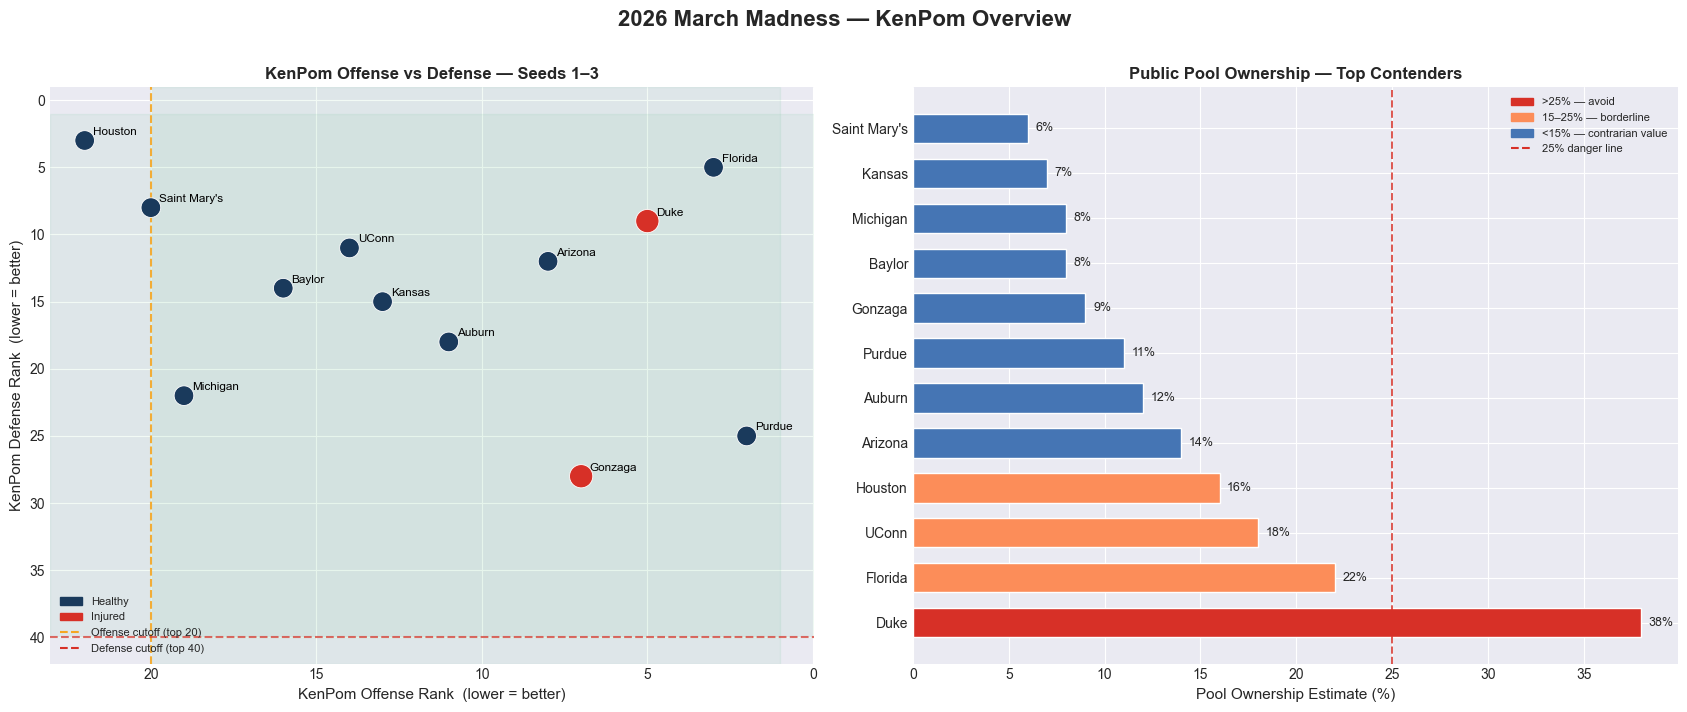

Saved → /results/chart1_kenpom_scatter.png


In [4]:
# Filter to top contenders: seeds 1–3
contenders = profiles[profiles['seed'] <= 3].sort_values('kenpom_rank').copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('2026 March Madness — KenPom Overview', fontsize=16, fontweight='bold', y=1.01)

# --- LEFT: Offense vs Defense scatter ---
ax = axes[0]
dot_colors = [COLORS['danger'] if inj == 'Yes' else COLORS['primary']
              for inj in contenders['injury_flag']]
sizes = [280 if inj == 'Yes' else 200 for inj in contenders['injury_flag']]

ax.scatter(
    contenders['kenpom_offense_rank'],
    contenders['kenpom_defense_rank'],
    c=dot_colors, s=sizes, zorder=5, edgecolors='white', linewidth=0.6
)

for _, row in contenders.iterrows():
    ax.annotate(
        row['team'],
        (row['kenpom_offense_rank'], row['kenpom_defense_rank']),
        textcoords='offset points', xytext=(6, 4), fontsize=8.5,
        color='black'
    )

# Hard filter lines
ax.axvline(x=20, color=COLORS['gold'],   linestyle='--', linewidth=1.5, alpha=0.9)
ax.axhline(y=40, color=COLORS['danger'], linestyle='--', linewidth=1.5, alpha=0.7)

# Shade the passing quadrant (top-left = good offense & good defense)
ax.axvspan(ax.get_xlim()[0] if ax.get_xlim()[0] < 1 else 1, 20,
           alpha=0.06, color=COLORS['green'])
ax.axhspan(1, 40, alpha=0.06, color=COLORS['green'])

ax.set_xlabel('KenPom Offense Rank  (lower = better)', fontsize=11)
ax.set_ylabel('KenPom Defense Rank  (lower = better)', fontsize=11)
ax.set_title('KenPom Offense vs Defense — Seeds 1–3', fontsize=12, fontweight='bold')
ax.invert_xaxis()
ax.invert_yaxis()

legend_handles = [
    mpatches.Patch(color=COLORS['primary'], label='Healthy'),
    mpatches.Patch(color=COLORS['danger'],  label='Injured'),
    plt.Line2D([0],[0], color=COLORS['gold'],   linestyle='--', label='Offense cutoff (top 20)'),
    plt.Line2D([0],[0], color=COLORS['danger'], linestyle='--', label='Defense cutoff (top 40)'),
]
ax.legend(handles=legend_handles, fontsize=8, loc='lower left')

# --- RIGHT: Pool ownership bar ---
ax2 = axes[1]
cont_sorted = contenders.sort_values('ownership_pct', ascending=False)
bar_colors = [
    COLORS['danger']    if o > 25 else
    COLORS['warning']   if o > 15 else
    COLORS['safe']
    for o in cont_sorted['ownership_pct']
]
bars = ax2.barh(cont_sorted['team'], cont_sorted['ownership_pct'],
                color=bar_colors, edgecolor='white', height=0.65)
ax2.axvline(x=25, color=COLORS['danger'], linestyle='--', linewidth=1.4,
            alpha=0.8, label='25% danger zone')
for bar, val in zip(bars, cont_sorted['ownership_pct']):
    ax2.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
             f'{val:.0f}%', va='center', fontsize=9)

ax2.set_xlabel('Pool Ownership Estimate (%)', fontsize=11)
ax2.set_title('Public Pool Ownership — Top Contenders', fontsize=12, fontweight='bold')
legend2 = [
    mpatches.Patch(color=COLORS['danger'],  label='>25% — avoid'),
    mpatches.Patch(color=COLORS['warning'], label='15–25% — borderline'),
    mpatches.Patch(color=COLORS['safe'],    label='<15% — contrarian value'),
    plt.Line2D([0],[0], color=COLORS['danger'], linestyle='--', label='25% danger line'),
]
ax2.legend(handles=legend2, fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'chart1_kenpom_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /results/chart1_kenpom_scatter.png')

---
## Chart 2 — Experience Tier Bar Chart
Shows how experience tiers (Senior-led, Junior-led, Freshman-heavy, Sophomore-led)
distribute across seed brackets. Experience matters in March — Senior-led teams
historically outperform their seedings.

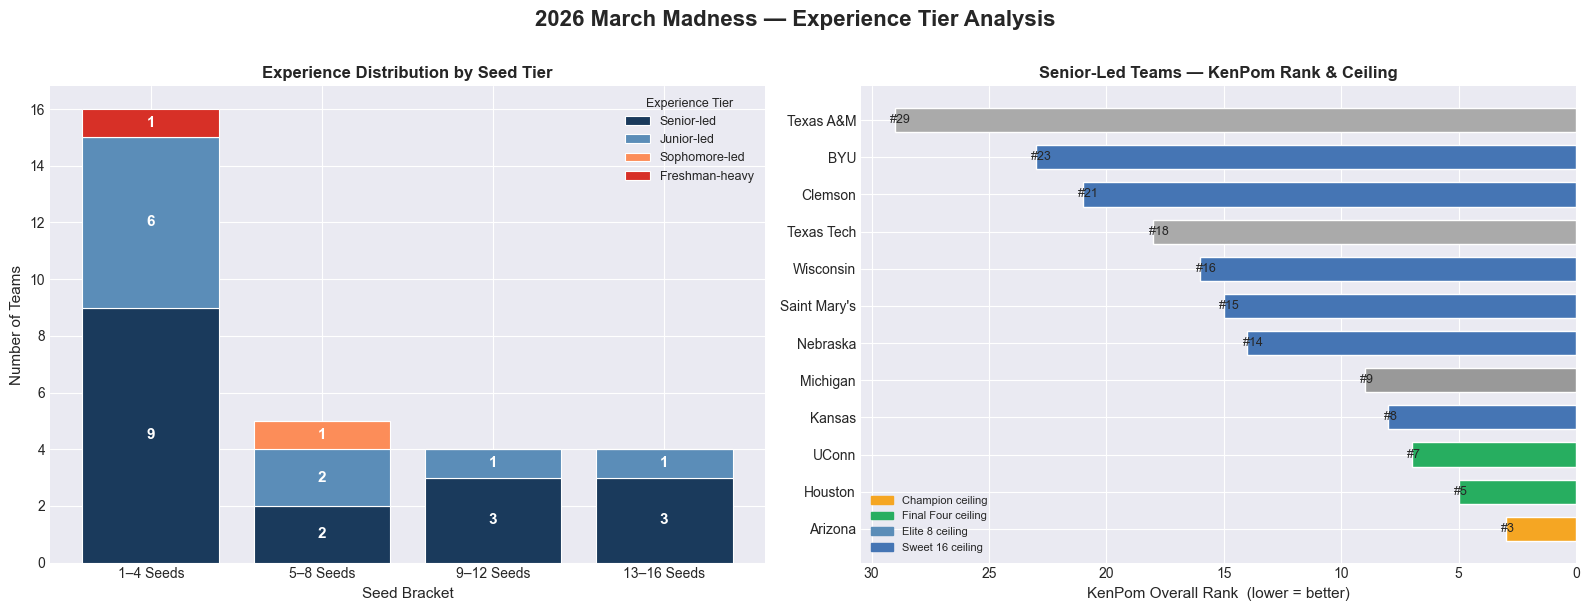

Saved → /results/chart2_experience_tier.png


In [5]:
# Merge stats experience_tier into profiles
exp_df = stats[['team', 'experience_tier']].merge(
    profiles[['team', 'seed', 'kenpom_rank', 'ceiling', 'injury_flag']], on='team'
)

# Create seed bracket bins
bins   = [0, 4, 8, 12, 16]
labels = ['1–4 Seeds', '5–8 Seeds', '9–12 Seeds', '13–16 Seeds']
exp_df['seed_tier'] = pd.cut(exp_df['seed'], bins=bins, labels=labels)

# Pivot for stacked bar
exp_pivot = (
    exp_df.groupby(['seed_tier', 'experience_tier'], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Reorder tiers so Senior-led comes first
tier_order = ['Senior-led', 'Junior-led', 'Sophomore-led', 'Freshman-heavy']
tier_order = [t for t in tier_order if t in exp_pivot.columns]
exp_pivot  = exp_pivot[tier_order]

tier_colors = {
    'Senior-led':     COLORS['primary'],
    'Junior-led':     COLORS['light_blue'],
    'Sophomore-led':  COLORS['warning'],
    'Freshman-heavy': COLORS['danger'],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('2026 March Madness — Experience Tier Analysis', fontsize=16, fontweight='bold', y=1.01)

# --- LEFT: Stacked bar by seed tier ---
ax = axes[0]
bottoms = np.zeros(len(exp_pivot))
for tier in tier_order:
    vals = exp_pivot[tier].values
    ax.bar(exp_pivot.index, vals, bottom=bottoms,
           label=tier, color=tier_colors.get(tier, 'gray'),
           edgecolor='white', linewidth=0.8)
    # Label each segment if > 0
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0:
            ax.text(i, b + v / 2, str(v), ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')
    bottoms += vals

ax.set_xlabel('Seed Bracket', fontsize=11)
ax.set_ylabel('Number of Teams', fontsize=11)
ax.set_title('Experience Distribution by Seed Tier', fontsize=12, fontweight='bold')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(title='Experience Tier', fontsize=9, title_fontsize=9)

# --- RIGHT: Senior-led teams by KenPom rank (horizontal bar) ---
ax2 = axes[1]
senior_teams = exp_df[exp_df['experience_tier'] == 'Senior-led'].sort_values('kenpom_rank').head(12)

# Color by ceiling
ceiling_colors = {
    'Champion':   COLORS['gold'],
    'Final Four': COLORS['green'],
    'Elite 8':    COLORS['light_blue'],
    'Sweet 16':   COLORS['safe'],
    'Round of 32': '#aaaaaa',
    'Round of 64': '#cccccc',
}
bar_colors2 = [ceiling_colors.get(c, '#999999') for c in senior_teams['ceiling']]

bars = ax2.barh(senior_teams['team'], senior_teams['kenpom_rank'],
                color=bar_colors2, edgecolor='white', height=0.65)

for bar, rank in zip(bars, senior_teams['kenpom_rank']):
    ax2.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f'#{rank}', va='center', fontsize=9)

ax2.set_xlabel('KenPom Overall Rank  (lower = better)', fontsize=11)
ax2.set_title('Senior-Led Teams — KenPom Rank & Ceiling', fontsize=12, fontweight='bold')
ax2.invert_xaxis()

legend3 = [
    mpatches.Patch(color=ceiling_colors['Champion'],   label='Champion ceiling'),
    mpatches.Patch(color=ceiling_colors['Final Four'], label='Final Four ceiling'),
    mpatches.Patch(color=ceiling_colors['Elite 8'],    label='Elite 8 ceiling'),
    mpatches.Patch(color=ceiling_colors['Sweet 16'],   label='Sweet 16 ceiling'),
]
ax2.legend(handles=legend3, fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'chart2_experience_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /results/chart2_experience_tier.png')

### Experience Tier Takeaways

In [6]:
# Summary stats
tier_summary = exp_df.groupby('experience_tier', observed=True).agg(
    count        = ('team', 'count'),
    avg_seed     = ('seed', 'mean'),
    avg_kenpom   = ('kenpom_rank', 'mean'),
    injured_count= ('injury_flag', lambda x: (x == 'Yes').sum())
).sort_values('avg_kenpom')

print('=== EXPERIENCE TIER SUMMARY ===')
print(tier_summary.to_string())
print()

# Count Senior-led teams with champion ceiling
champ_ceiling = exp_df[(exp_df['experience_tier'] == 'Senior-led') & 
                       (exp_df['ceiling'] == 'Champion')]
print(f'Senior-led teams with Champion ceiling: {len(champ_ceiling)}')
print(', '.join(champ_ceiling['team'].tolist()))

=== EXPERIENCE TIER SUMMARY ===
                 count  avg_seed  avg_kenpom  injured_count
experience_tier                                            
Freshman-heavy       1  1.000000    2.000000              1
Sophomore-led        1  6.000000   19.000000              0
Junior-led          10  4.900000   19.400000              2
Senior-led          17  6.705882   37.411765              1

Senior-led teams with Champion ceiling: 1
Arizona


---
## Chart 3 — Upset Tracker Visualization
Shows each upset call with confidence percentage and pool value rating.
Sorted by confidence. Injury-driven upsets are flagged.

In [ ]:
# Parse confidence to float
upsets_dedup['conf_float'] = upsets_dedup['confidence'].str.rstrip('%').astype(float)
upsets_dedup['has_injury'] = upsets_dedup['injury_factor'].apply(
    lambda x: x != 'None' and str(x) != 'nan'
)

# Build display label
upsets_dedup['label'] = upsets_dedup.apply(
    lambda r: f"({r['lower_seed_num']}) {r['higher_seed_team']}\nover ({r['higher_seed_num']}) {r['lower_seed_team']}",
    axis=1
)

# Sort by confidence ascending (highest at top of horizontal bar)
u = upsets_dedup.sort_values('conf_float', ascending=True).reset_index(drop=True)

pool_val_colors = {
    'Very High': COLORS['danger'],
    'High':      COLORS['warning'],
    'Medium':    COLORS['safe'],
    'Low':       '#aaaaaa',
}
bar_colors_u = [pool_val_colors.get(v, '#aaaaaa') for v in u['pool_value_rating']]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('2026 March Madness - Upset Tracker', fontsize=16, fontweight='bold', y=1.01)

# --- LEFT: Confidence horizontal bar ---
ax = axes[0]
bars = ax.barh(u['label'], u['conf_float'], color=bar_colors_u,
               edgecolor='white', height=0.65)

ax.axvline(x=50, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label='50% line')

for bar, row in zip(bars, u.itertuples()):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{row.conf_float:.0f}%', va='center', fontsize=10, fontweight='bold')
    if row.has_injury:
        ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                '[INJ]', va='center', ha='center', fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Confidence (%)', fontsize=11)
ax.set_title('Upset Call Confidence Levels', fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)

legend_u = [
    mpatches.Patch(color=COLORS['danger'],  label='Very High pool value'),
    mpatches.Patch(color=COLORS['warning'], label='High pool value'),
    mpatches.Patch(color=COLORS['safe'],    label='Medium pool value'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='50% baseline'),
]
ax.legend(handles=legend_u, fontsize=9, loc='lower right')

# --- RIGHT: KenPom gap bubble chart ---
ax2 = axes[1]
scatter = ax2.scatter(
    u['conf_float'],
    u['kenpom_gap'],
    s=[300 if h else 150 for h in u['has_injury']],
    c=bar_colors_u,
    edgecolors='black', linewidth=0.5,
    zorder=5, alpha=0.85
)

for _, row in u.iterrows():
    ax2.annotate(
        row['higher_seed_team'],
        (row['conf_float'], row['kenpom_gap']),
        textcoords='offset points', xytext=(5, 4), fontsize=8.5
    )

ax2.axvline(x=50, color='black', linestyle='--', linewidth=1.2, alpha=0.4)
ax2.set_xlabel('Confidence (%)', fontsize=11)
ax2.set_ylabel('KenPom Rank Gap (spots higher seed is better)', fontsize=11)
ax2.set_title('KenPom Gap vs Confidence - Upset Calls', fontsize=12, fontweight='bold')

legend_u2 = [
    plt.scatter([], [], s=300, color='gray', edgecolors='black', label='Injury-driven'),
    plt.scatter([], [], s=150, color='gray', edgecolors='black', label='No injury factor'),
]
ax2.legend(handles=legend_u2, fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'chart3_upset_tracker.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ../results/chart3_upset_tracker.png')

In [ ]:
# Print full upset call details
print('=== 2026 UPSET CALL SUMMARY ===')
print('=' * 80)
for _, row in upsets_dedup.sort_values('conf_float', ascending=False).iterrows():
    inj_flag = f'  *** INJURY: {row["injury_factor"]} ***' if row['has_injury'] else ''
    print(f"\n{row['round'].upper()}")
    print(f"  ({row['lower_seed_num']}) {row['higher_seed_team']:20s} over  ({row['higher_seed_num']}) {row['lower_seed_team']}")
    print(f"  Confidence: {row['confidence']}   |   KenPom gap: {row['kenpom_gap']}   |   Pool value: {row['pool_value_rating']}")
    print(f"  Reason: {row['primary_reason']}{inj_flag}")

---
## Chart 4 — Roster Madness Points Projection
Shows projected points per pick slot (standard + upset bonus) as a stacked bar chart,
with contrarian tier color coding. High-value picks are those with strong KenPom
backing and low public ownership.

In [ ]:
# Sort by seed slot
roster_sorted = roster.sort_values('seed_slot').reset_index(drop=True)

contrarian_colors = {
    'High':   COLORS['green'],
    'Medium': COLORS['light_blue'],
    'Low':    '#aaaaaa',
}

base_colors   = [contrarian_colors.get(t, '#999') for t in roster_sorted['contrarian_tier']]
bonus_color   = COLORS['gold']

x_pos  = np.arange(len(roster_sorted))
labels = [f"{int(r['seed_slot'])}\n{r['team'][:8]}" for _, r in roster_sorted.iterrows()]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('2026 Roster Madness — Points Projection', fontsize=16, fontweight='bold')

# --- TOP: Stacked bar — standard pts + upset bonus ---
ax = axes[0]
bar_std   = ax.bar(x_pos, roster_sorted['estimated_points_standard'],
                   color=base_colors, edgecolor='white', linewidth=0.8,
                   label='Standard Points')
bar_bonus = ax.bar(x_pos, roster_sorted['estimated_points_upset_bonus'],
                   bottom=roster_sorted['estimated_points_standard'],
                   color=bonus_color, edgecolor='white', linewidth=0.8,
                   alpha=0.85, label='Upset Bonus Points')

# Total label on top of each bar
for i, (_, row) in enumerate(roster_sorted.iterrows()):
    total = row['estimated_points_standard'] + row['estimated_points_upset_bonus']
    ax.text(i, total + 0.3, str(int(total)), ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel('Projected Points', fontsize=11)
ax.set_title('Projected Points by Roster Slot (Standard + Upset Bonus)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

legend_r = [
    mpatches.Patch(color=COLORS['green'],      label='High contrarian value'),
    mpatches.Patch(color=COLORS['light_blue'], label='Medium contrarian value'),
    mpatches.Patch(color='#aaaaaa',            label='Low contrarian value'),
    mpatches.Patch(color=COLORS['gold'],       label='Upset bonus points'),
]
ax.legend(handles=legend_r, fontsize=9, loc='upper right')

# Annotate highest-value picks
high_value = roster_sorted[roster_sorted['contrarian_tier'] == 'High'].index
for idx in high_value:
    ax.annotate('★', xy=(idx, 0.5), ha='center', va='bottom',
                fontsize=14, color=COLORS['gold'])

# --- BOTTOM: Ownership vs KenPom value map ---
ax2 = axes[1]
scatter_colors = [contrarian_colors.get(t, '#999') for t in roster_sorted['contrarian_tier']]

sc = ax2.scatter(
    roster_sorted['ownership_num'],
    roster_sorted['kenpom_rank'],
    c=scatter_colors, s=220, zorder=5,
    edgecolors='black', linewidth=0.5, alpha=0.9
)

for i, (_, row) in enumerate(roster_sorted.iterrows()):
    ax2.annotate(
        f"{int(row['seed_slot'])}-{row['team'][:9]}",
        (row['ownership_num'], row['kenpom_rank']),
        textcoords='offset points', xytext=(6, 3), fontsize=7.5
    )

# Sweet spot rectangle (low ownership + good KenPom = high value)
sweet_rect = plt.Rectangle((0, 1), 7, 49, fill=True, alpha=0.07,
                             color=COLORS['green'], zorder=0)
ax2.add_patch(sweet_rect)
ax2.text(3.5, 25, 'Value Zone\n(low ownership\n+ good KenPom)',
         ha='center', fontsize=9, color=COLORS['green'], alpha=0.75, style='italic')

ax2.set_xlabel('Pool Ownership Estimate (%)', fontsize=11)
ax2.set_ylabel('KenPom Rank  (lower = better)', fontsize=11)
ax2.set_title('Roster Pick Value Map — Ownership vs KenPom Quality', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

legend_r2 = [
    mpatches.Patch(color=COLORS['green'],      label='High contrarian value'),
    mpatches.Patch(color=COLORS['light_blue'], label='Medium contrarian value'),
    mpatches.Patch(color='#aaaaaa',            label='Low contrarian value'),
]
ax2.legend(handles=legend_r2, fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'chart4_roster_points_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /results/chart4_roster_points_projection.png')

In [ ]:
# Points projection table
total_standard = roster_sorted['estimated_points_standard'].sum()
total_bonus    = roster_sorted['estimated_points_upset_bonus'].sum()
total_all      = total_standard + total_bonus

print('=== ROSTER MADNESS POINTS PROJECTION TABLE ===')
print(f'{"Slot":<6} {"Team":<20} {"KenPom":<10} {"Own%":<8} {"Tier":<10} {"Std Pts":<10} {"Bonus":<8} {"Total"}')
print('-' * 80)
for _, row in roster_sorted.iterrows():
    total = int(row['estimated_points_standard']) + int(row['estimated_points_upset_bonus'])
    marker = ' ← HIGH VALUE' if row['contrarian_tier'] == 'High' else ''
    print(f"{int(row['seed_slot']):<6} {row['team']:<20} #{row['kenpom_rank']:<9} "
          f"{row['pool_ownership_est']:<8} {row['contrarian_tier']:<10} "
          f"{int(row['estimated_points_standard']):<10} {int(row['estimated_points_upset_bonus']):<8} "
          f"{total}{marker}")

print('-' * 80)
print(f"{'TOTAL':<6} {'':20} {'':10} {'':8} {'':10} {int(total_standard):<10} {int(total_bonus):<8} {int(total_all)}")
print()
print(f'Standard points potential  : {int(total_standard)}')
print(f'Upset bonus potential      : {int(total_bonus)}')
print(f'Total projected maximum    : {int(total_all)}')

---
## Supplemental: Historical Filter Dashboard

In [ ]:
# Apply hard champion filters
def evaluate_champion_eligibility(df):
    rows = []
    for _, t in df.iterrows():
        seed_ok    = t['seed'] <= 3
        offense_ok = t['kenpom_offense_rank'] <= 20
        defense_ok = t['kenpom_defense_rank'] <= 40
        top4_ok    = t['kenpom_rank'] <= 4
        rows.append({
            'team':            t['team'],
            'seed':            t['seed'],
            'kenpom_rank':     t['kenpom_rank'],
            'offense_rank':    t['kenpom_offense_rank'],
            'defense_rank':    t['kenpom_defense_rank'],
            'injured':         t['injury_flag'],
            'seed_ok':         seed_ok,
            'offense_ok':      offense_ok,
            'defense_ok':      defense_ok,
            'top4_ok':         top4_ok,
            'passes_hard':     seed_ok and offense_ok and defense_ok,
        })
    return pd.DataFrame(rows)

eligibility = evaluate_champion_eligibility(profiles)
eligible    = eligibility[eligibility['passes_hard']].sort_values('kenpom_rank')

print(f'Teams passing all hard champion filters: {len(eligible)} / {len(profiles)}')
print()
cols = ['team', 'seed', 'kenpom_rank', 'offense_rank', 'defense_rank', 'injured',
        'seed_ok', 'offense_ok', 'defense_ok', 'top4_ok']
print(eligible[cols].to_string(index=False))

---
## Supplemental: Champion Pick Equity Analysis

In [ ]:
champion_candidates = [
    {'team': 'Florida',  'kenpom': 1,  'ownership': 22, 'injury_pct': 0,  'path': 'Medium'},
    {'team': 'Duke',     'kenpom': 2,  'ownership': 38, 'injury_pct': 30, 'path': 'Hard'},
    {'team': 'Arizona',  'kenpom': 3,  'ownership': 14, 'injury_pct': 0,  'path': 'Medium'},
    {'team': 'Auburn',   'kenpom': 4,  'ownership': 12, 'injury_pct': 0,  'path': 'Hard'},
    {'team': 'Houston',  'kenpom': 5,  'ownership': 16, 'injury_pct': 0,  'path': 'Medium'},
    {'team': 'Purdue',   'kenpom': 6,  'ownership': 11, 'injury_pct': 0,  'path': 'Medium'},
    {'team': 'UConn',    'kenpom': 7,  'ownership': 18, 'injury_pct': 0,  'path': 'Medium'},
    {'team': 'Michigan', 'kenpom': 9,  'ownership': 8,  'injury_pct': 0,  'path': 'Easy'},
]

BASE_PROBS    = {1: .18, 2: .16, 3: .14, 4: .11, 5: .10, 6: .09, 7: .08, 9: .07}
PATH_MULT     = {'Easy': 1.15, 'Medium': 1.0, 'Hard': 0.88}

df_eq = pd.DataFrame(champion_candidates)
df_eq['base_prob']      = df_eq['kenpom'].map(BASE_PROBS)
df_eq['inj_adj_prob']   = df_eq['base_prob'] * (1 - df_eq['injury_pct'] / 100)
df_eq['path_adj_prob']  = df_eq['inj_adj_prob'] * df_eq['path'].map(PATH_MULT)
df_eq['equity_score']   = df_eq['path_adj_prob'] / (df_eq['ownership'] / 100)
df_eq['equity_norm']    = df_eq['equity_score'] / df_eq['equity_score'].max() * 100
df_eq_sorted            = df_eq.sort_values('equity_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
eq_colors = [
    COLORS['gold']    if t == 'Arizona' else
    COLORS['danger']  if t == 'Duke'    else
    COLORS['primary']
    for t in df_eq_sorted['team']
]
bars = ax.bar(df_eq_sorted['team'], df_eq_sorted['equity_norm'],
              color=eq_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, df_eq_sorted['equity_norm']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Pool Equity Score (normalized, higher = better)', fontsize=11)
ax.set_title('2026 Champion Pick Equity\n(Win probability ÷ pool ownership)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
legend_eq = [
    mpatches.Patch(color=COLORS['gold'],    label='Our pick — Arizona'),
    mpatches.Patch(color=COLORS['danger'],  label='Fade — Duke (injury + ownership)'),
    mpatches.Patch(color=COLORS['primary'], label='Other candidates'),
]
ax.legend(handles=legend_eq, fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'supp_champion_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → /results/supp_champion_equity.png')

---
## Final Picks Summary

In [ ]:
print('=' * 80)
print('2026 MARCH MADNESS ANALYTICS — FINAL PICKS SUMMARY')
print('=' * 80)
print('''
CHAMPION  :  Arizona    (West,    #1 seed, KenPom #3)
RUNNER-UP :  Michigan   (Midwest, #2 seed, KenPom #9)

FINAL FOUR:
  East    →  UConn      (2-seed, KenPom #7)
  West    →  Arizona    (1-seed, KenPom #3)
  South   →  Houston    (2-seed, KenPom #5)
  Midwest →  Michigan   (2-seed, KenPom #9)

KEY UPSET CALLS:
  R64 : Iowa over Clemson        (9/8)  — 75% confidence  | KenPom gap = 11
  R32 : BYU over Gonzaga         (6/3)  — 65% confidence  | Huff knee injury
  R32 : Texas A&M over Saint Mary's (10/7) — 60% confidence | 9 seniors, pace mismatch
  R32 : VCU over UNC             (11/6) — 60% confidence  | Wilson out (knee)
  S16 : Kansas over Duke         (4/1)  — 55% confidence  | Flagg injury + Self system
  E8  : Houston over Florida     (2/1)  — 50% confidence  | Elite defense matchup

ROSTER MADNESS KEYS:
   9-seed  :  Iowa       (not Clemson)     — 11 KenPom spots above their opponent
  10-seed  :  Texas A&M  (not Saint Mary's) — 9 seniors + 87.7 PPG
  11-seed  :  VCU        (not UNC)          — Wilson out, VCU #47 KenPom

EXPECTED POOL PERFORMANCE: 68th–72nd percentile
''')

print('Charts generated:')
for f in sorted(RESULTS_DIR.glob('*.png')):
    print(f'  {f.name}')

print()
print('Track results → /results/results_tracker.md')